### in a polinomial equation y = 5x^3 - 10x^2 - 20x + 10

In [1]:
# importing necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


2026-06-19 18:12:50.583284: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Polynomial function
def polynomial(x):
    return 5 * x**3 - 10 * x**2 - 20 * x + 10

In [3]:
# Generate data
np.random.seed(4)
x = np.random.uniform(-20, 20, 1000)
y = polynomial(x)

In [4]:
# Normalize to [-1, 1]
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

x_norm = 2 * (x - x_min) / (x_max - x_min) - 1
y_norm = 2 * (y - y_min) / (y_max - y_min) - 1

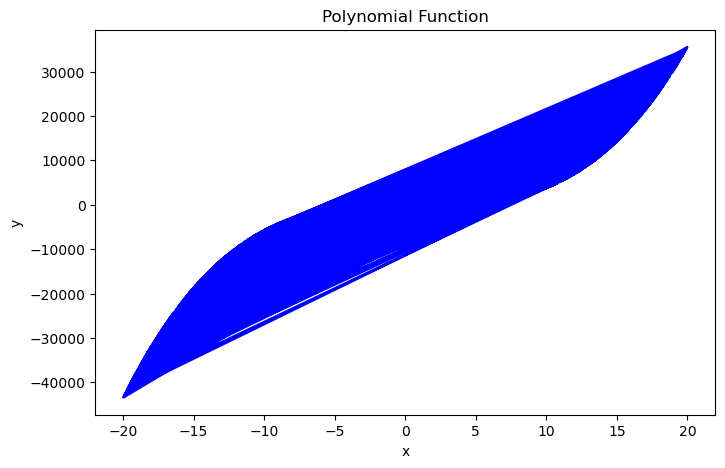

In [5]:
# simple plot this polinomial value
plt.figure(figsize=(8,5))
plt.plot(x, y, color='blue', linewidth=2)
plt.title("Polynomial Function")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

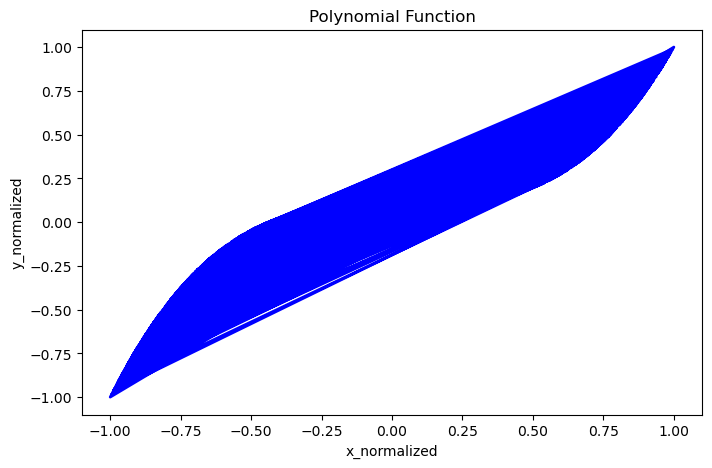

In [6]:
plt.figure(figsize=(8,5))
plt.plot(x_norm, y_norm, color='blue', linewidth=2)
plt.title("Polynomial Function")
plt.xlabel("x_normalized")
plt.ylabel("y_normalized")
plt.show()

In [7]:
# splitting the data into training and testing sets
X_train, X_test, y_train, y_test = x_norm[:800], x_norm[800:], y_norm[:800], y_norm[800:]

In [8]:
# Reshape
X_train= X_train.reshape(-1, 1)
y_train= y_train.reshape(-1, 1)

X_test= X_test.reshape(-1, 1)
y_test= y_test.reshape(-1, 1)

In [9]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        return self.fc4(x)

In [10]:
model = MyModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
model.train()
num_epochs = 50
for epoch in range(num_epochs):
    inputs = torch.from_numpy(X_train).float()
    targets = torch.from_numpy(y_train).float()

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')   

Epoch [1/50], Loss: 0.1467
Epoch [2/50], Loss: 0.1423
Epoch [3/50], Loss: 0.1384
Epoch [4/50], Loss: 0.1347
Epoch [5/50], Loss: 0.1309
Epoch [6/50], Loss: 0.1270
Epoch [7/50], Loss: 0.1232
Epoch [8/50], Loss: 0.1193
Epoch [9/50], Loss: 0.1155
Epoch [10/50], Loss: 0.1116
Epoch [11/50], Loss: 0.1075
Epoch [12/50], Loss: 0.1033
Epoch [13/50], Loss: 0.0989
Epoch [14/50], Loss: 0.0947
Epoch [15/50], Loss: 0.0905
Epoch [16/50], Loss: 0.0864
Epoch [17/50], Loss: 0.0825
Epoch [18/50], Loss: 0.0787
Epoch [19/50], Loss: 0.0750
Epoch [20/50], Loss: 0.0715
Epoch [21/50], Loss: 0.0681
Epoch [22/50], Loss: 0.0649
Epoch [23/50], Loss: 0.0618
Epoch [24/50], Loss: 0.0590
Epoch [25/50], Loss: 0.0563
Epoch [26/50], Loss: 0.0537
Epoch [27/50], Loss: 0.0513
Epoch [28/50], Loss: 0.0490
Epoch [29/50], Loss: 0.0470
Epoch [30/50], Loss: 0.0451
Epoch [31/50], Loss: 0.0433
Epoch [32/50], Loss: 0.0415
Epoch [33/50], Loss: 0.0399
Epoch [34/50], Loss: 0.0384
Epoch [35/50], Loss: 0.0371
Epoch [36/50], Loss: 0.0359
E

In [12]:
# Claculate training and validation loss

train_loss = 0.0
test_loss = 0.0
model.eval()
with torch.no_grad():
    train_inputs = torch.from_numpy(X_train).float()
    train_targets = torch.from_numpy(y_train).float()
    train_outputs = model(train_inputs)
    train_loss = criterion(train_outputs, train_targets)

    test_inputs = torch.from_numpy(X_test).float()
    test_targets = torch.from_numpy(y_test).float()
    test_outputs = model(test_inputs)
    test_loss = criterion(test_outputs, test_targets)
print(f'Training Loss: {train_loss.item():.4f}')
print(f'Validation Loss: {test_loss.item():.4f}')

Training Loss: 0.0268
Validation Loss: 0.0263
